# Hotstart and chained runs

**What this shows:** how to save the state of an XBeach run and start a second run
from it, for example to split a long simulation or to skip spin-up.

**Prerequisites:** [Output](output.ipynb) and
[Tutorial 1](../tutorial/01_first_model.ipynb#8.-Run-XBeach) for running XBeach with
Docker.

**You will learn:**

- how to write hotstart files with `Output(writehotstart=True, tinth=...)`
- how to start a run from them with `Hotstart(hotstartfileno=..., previous_run=...)`
- what must stay the same between chained runs

**Data used:** `bathy.tif` and `ww3-spectra-20230101-short.nc`. The model runs use the XBeach Docker image and are skipped
if Docker is not available.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun
from rompy_xbeach.components.boundary.parameters import TideBoundaryConditions
from rompy_xbeach.components.output import Output
from rompy_xbeach.components.physics import Physics
from rompy_xbeach.components.physics.wavemodel import Surfbeat
from rompy_xbeach.config import Config, DataInterface
from rompy_xbeach.data.bathy import SeawardExtensionLinear, XBeachBathy
from rompy_xbeach.data.boundary import BoundaryStationSpectraJons
from rompy_xbeach.grid import RegularGrid
from rompy_xbeach.source import SourceCRSWavespectra, SourceGeotiff

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "hotstart_and_chained_runs"
shutil.rmtree(OUT_DIR, ignore_errors=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=20.0,
    dy=30.0,
    nx=115,
    ny=110,
    crs=28350,
)
bathy = XBeachBathy(
    source=SourceGeotiff(filename=DATA_DIR / "bathy.tif"),
    posdwn=False,
    extension=SeawardExtensionLinear(depth=15.0, slope=0.05),
)
wave = BoundaryStationSpectraJons(
    source=SourceCRSWavespectra(
        uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
    ),
    location="offshore",
    sel_method="nearest",
    thetamin=-90.0,
    thetamax=90.0,
    dtheta_s=10.0,
)
backend = DockerConfig(image="ghcr.io/rom-py/xbeach:r6147", executable="xbeach")


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_model(run_id, period, output, hotstart=None):
    """Generate and run a model that differs only in period, output and hotstart."""
    config = Config(
        grid=grid,
        bathy=bathy,
        input=DataInterface(wave=wave),
        physics=Physics(wavemodel=Surfbeat()),
        tide_boundary=TideBoundaryConditions(tideloc=0, zs0=0.0),
        output=output,
        hotstart=hotstart,
    )
    modelrun = ModelRun(run_id=run_id, period=period, output_dir=OUT_DIR, config=config)
    workspace = Path(modelrun())
    ok = modelrun.run(backend, workspace_dir=workspace)
    print(f"{run_id}: {'finished' if ok else 'failed'}")
    return workspace


RUN_MODELS = docker_available()
print("Docker available:", RUN_MODELS)

Docker available: True


## 1. First run: write hotstart files

`writehotstart=True` saves the model state every `tinth` seconds. Each save is a set
of files `hotstart_<variable><number>.dat`, numbered from 1.

In [2]:
first_period = TimeRange(
    start="2023-01-01T00:00", end="2023-01-01T00:20", interval="10m"
)
first_output = Output(globalvars=["zs"], tintg=60.0, writehotstart=True, tinth=600.0)

if RUN_MODELS:
    first = run_model("first_run", first_period, first_output)
    print(sorted({p.name[-10:-4] for p in first.glob("hotstart_*.dat")}), "saved")
    print(sorted(p.name for p in first.glob("hotstart_*000002.dat")))

first_run: finished
['000001', '000002'] saved
['hotstart_ccg000002.dat', 'hotstart_ee000002.dat', 'hotstart_ee_s000002.dat', 'hotstart_kturb000002.dat', 'hotstart_rr000002.dat', 'hotstart_umean000002.dat', 'hotstart_uu000002.dat', 'hotstart_vmean000002.dat', 'hotstart_vv000002.dat', 'hotstart_zb000002.dat', 'hotstart_zs000002.dat']


## 2. Second run: start from a hotstart

`Hotstart` chooses the saved state with `hotstartfileno` and copies its files from the
previous run with `previous_run`. The second run starts where the first ended, so its
period starts at 00:20.

In [3]:
from rompy_xbeach.components.hotstart import Hotstart
from rompy_xbeach.types import XBeachDirectoryBlob

if RUN_MODELS:
    second = run_model(
        "second_run",
        TimeRange(start="2023-01-01T00:20", end="2023-01-01T00:40", interval="10m"),
        Output(globalvars=["zs"], tintg=60.0),
        hotstart=Hotstart(
            hotstartfileno=2, previous_run=XBeachDirectoryBlob(source=str(first))
        ),
    )
    print(
        [
            line
            for line in (second / "params.txt").read_text().splitlines()
            if "hotstart" in line
        ]
    )

second_run: finished
['hotstart = 1', 'hotstartfileno = 2']


The mean water level near the shore continues smoothly from one run into the next,
without the spin-up the first run needed:

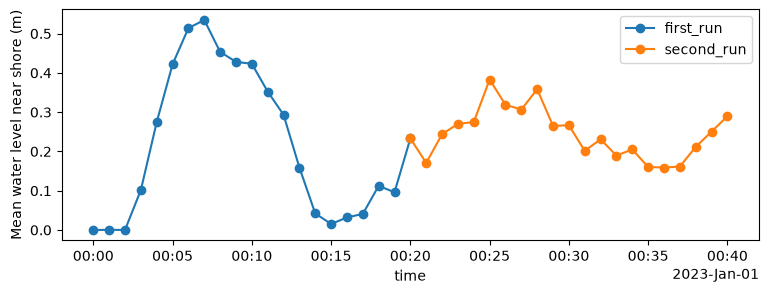

In [4]:
if RUN_MODELS:
    fig, ax = plt.subplots(figsize=(9, 3))
    for workspace in (first, second):
        ds = xr.open_dataset(workspace / "xboutput.nc")
        nearshore = ds.zs.isel(nx=slice(-40, -20)).mean(["nx", "ny"])
        nearshore.plot(ax=ax, marker="o", label=workspace.name)
    ax.set_ylabel("Mean water level near shore (m)")
    ax.legend()
    plt.show()

## 3. What must match

- **Grid and bathymetry:** hotstart files hold arrays on the original grid, so `nx`,
  `ny` and any extensions must be identical.
- **Model settings:** use the same physics, and the same MPI layout if MPI is used.
- **Forcing:** give the second run forcing for its own period. To reuse exactly the same
  wave time series, see [waves from files and reuse](waves_from_files_and_reuse.ipynb).

If the hotstart files are already in the workspace, `Config(hotstart=True)` enables
hotstart with file number 0, without copying anything.

## Summary

- `Output(writehotstart=True, tinth=...)` saves numbered model states.
- `Hotstart(hotstartfileno=n, previous_run=...)` starts a run from state `n` of a
  previous run.
- Keep the grid and model settings identical between chained runs.